<h1>IPO Stocks Analysis</h1>

In [1]:
# First define these variables:

_months = 60 # Define number of months of data to scrape 
num_days = 180  # Define the number of days of stock data you want to retrieve
day_data = 'Adj Close' # Define the data for the days from this list ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time
import pandas as pd
from bs4 import BeautifulSoup

# Create a Chrome webdriver
driver = webdriver.Chrome()

# Open a webpage
driver.get('https://www.nasdaq.com/market-activity/ipos')

def replace_price_range(price):
    price_str = str(price)
    if '-' in price_str:
        low, high = map(float, price_str.split('-'))
        return (low + high) / 2
    if 'NA' in price_str:
        return None
    try:
        return float(price_str.replace(' ', '').replace(',', ''))
    except ValueError:
        print(f'Value error, price is {price_str}')
        return None
    
mapping = {
    'proposedTickerSymbol':'Symbol',
    'companyName':'Company Name',
    'proposedExchange':'Exchange/ Market',
    'proposedSharePrice':'Price',
    'sharesOffered':'Shares',
    'expectedPriceDate':'Expected IPO Date',
    'dollarValueOfSharesOffered':'Offer Amount',
    'pricedDate':'Date',
    'dealStatus':'Actions',
    'filedDate':'Date Filed',
    'withdrawDate':'Date Withdrawn'
}

dfs = []
for i in range(_months):
    # Find all buttons within the div
    buttons = driver.find_elements(By.CLASS_NAME, 'time-belt__item')

    # Click the 4th button (index 3 since indexing starts from 0)
    buttons[3].click()

    time.sleep(0.6)

    # Find tables within the container element by class name
    tables = driver.find_elements(By.CLASS_NAME, 'market-calendar-table--with-title')

    # Extract text or perform actions on the elements found
    data = ''
    for table in tables:
        data += table.get_attribute('outerHTML') + '\n\n'

    # Split the data into sections representing each table
    tables_list = data.split('\n\n')

    all_dfs = []
    for table in tables_list:
        soup = BeautifulSoup(table)

        # Get Table name from the h3 tag 
        name_tag = soup.find('h3', class_='market-calendar-table__title')
        if name_tag:
            name = name_tag.get_text() if name_tag else None
            #print(f'name is {name}')

            # Get first Table 
            first_table = soup.find('table')

            # Get Columns from text inside span tags inside thead tag
            thead = first_table.find('thead')

            columns = [span.text.strip() for span in thead.find_all('span', {'class': 'market-calendar-table__columnheader-text'})]
            #print(f'columns is {columns}\n')

            # Extract rows and populate DataFrame
            tbody = soup.find('tbody')
            rows = tbody.find_all('tr')

            data_dicts = []
            for row in rows:
                data_cells = row.find_all(['th', 'td'])
                # Extract text content and data-column attribute
                rows_data = [(cell.get('data-column'), cell.get_text(strip=True)) for cell in data_cells]
                # Convert rows_data to dictionary
                data_dict = {mapping[key]: value for key, value in rows_data}
                #print(f'rows_data is {data_dict}')
                data_dicts.append(data_dict)

            df = pd.DataFrame(data_dicts, columns=columns)
            df.name = name
            all_dfs.append(df)

    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Replace empty values with NaN
    combined_df = combined_df.replace('', pd.NA)

    try:
        # Convert 'Shares' and 'Offer Amount' to int64 after removing '$' and ','
        combined_df['Shares'] = combined_df['Shares'].str.replace(',', '').astype('Int64')
        combined_df['Offer Amount'] = combined_df['Offer Amount'].str.replace('$', '').str.replace(',', '').str.split('.').str[0].astype('Int64')

        # Convert 'Price' column to float64, taking the average of ranges
        combined_df['Price'] = combined_df['Price'].apply(replace_price_range)

        # Convert 'Date', 'Date Filed', and 'Date Withdrawn' to datetime
        combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')
        combined_df['Date Filed'] = pd.to_datetime(combined_df['Date Filed'], errors='coerce')
        combined_df['Date Withdrawn'] = pd.to_datetime(combined_df['Date Withdrawn'], errors='coerce')
    except KeyError:
        print(f'Key error, combined_df columns is {combined_df.columns}')

    # combined_df contains all the tables in the chosen month with all the data
    #display(combined_df)
    dfs.append(combined_df)
    
    prev_button = driver.find_element(By.CLASS_NAME, 'time-belt__prev')
    prev_button.click()

driver.quit()

all_dfs = pd.concat(dfs, ignore_index=True)

C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  combined_df['Offer Amount'] = combined_df['Offer Amount'].str.replace('$', '').str.replace(',', '').str.split('.').str[0].astype('Int64')
C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  combined_df['Offer Amount'] = combined_df['Offer Amount'].str.replace('$', '').str.replace(',', '').str.split('.').str[0].astype('Int64')
C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, singl

Value error, price is 10.00	​


C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  combined_df['Offer Amount'] = combined_df['Offer Amount'].str.replace('$', '').str.replace(',', '').str.split('.').str[0].astype('Int64')
C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  combined_df['Offer Amount'] = combined_df['Offer Amount'].str.replace('$', '').str.replace(',', '').str.split('.').str[0].astype('Int64')
C:\Users\user\AppData\Local\Temp\ipykernel_22760\4191601933.py:106: FutureWarning: The default value of regex will change from True to False in a future version. In addition, singl

In [3]:
filtered_df = all_dfs[['Symbol', 'Price', 'Date']].copy()
filtered_df = filtered_df.dropna(subset=['Symbol', 'Price', 'Date']).reset_index(drop=True)

display(filtered_df)

,Symbol,Price,Date
0,SIMAU,10.0,2024-07-10
1,EHGO,4.0,2024-07-02
2,EURKU,10.0,2024-07-02
3,LIF,27.0,2024-06-06
4,FLYE,4.0,2024-06-06
...,...,...,...
2047,SSPKU,10.0,2019-08-08
2048,THBRU,10.0,2019-08-09
2049,PLIN,5.0,2019-08-14
2050,CFB,14.5,2019-08-15


In [4]:
import yfinance as yf

symbol_list = filtered_df['Symbol'].unique().tolist()

yf.download('ATMCU')

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-12-30,10.08,10.11,10.08,10.11,10.11,1659100
2023-01-03,10.09,10.12,10.09,10.11,10.11,69500
2023-01-04,10.11,10.12,10.09,10.11,10.11,30800
2023-01-05,10.10,10.12,10.10,10.12,10.12,24400
2023-01-06,10.12,10.13,10.12,10.12,10.12,13700
...,...,...,...,...,...,...
2024-07-08,11.10,11.10,11.10,11.10,11.10,0
2024-07-09,11.10,11.10,11.10,11.10,11.10,0
2024-07-10,11.10,11.10,11.10,11.10,11.10,0


In [5]:
from datetime import timedelta

stock_cols = [f'D{i}' for i in range(1, num_days+1)]
All_singleRowStock_df = pd.DataFrame()

for index, row in filtered_df.iterrows():
    symbol = row['Symbol']
    stock_data = yf.download(symbol)
    
    if stock_data.empty:
        filtered_df.drop(index, inplace=True)
    else:
        stock_data = stock_data.iloc[:num_days].round(2)
        stock_data.drop([col for col in stock_data.columns if col != day_data], axis=1, inplace=True) 
        stock_data = stock_data.pivot_table(index='Date', aggfunc='first').reset_index()

        if stock_data.iloc[0]['Date'] != row['Date']: #incorrect data to merge
            print('1 executed')
            if stock_data.iloc[0]['Date'] > row['Date']: # stock_data later than filtered_df
                print('2 executed')
                # add earlier dates into stock_data with NaN values
                while True:
                    print('While executed')
                    new_date = stock_data.iloc[0]['Date'] - timedelta(days=1)
                    if new_date.weekday() == 6:
                        new_date -= timedelta(days=2)
                    new_row = pd.DataFrame({'Date': new_date, 'Adj Close': [None]})
                    stock_data = pd.concat([new_row, stock_data[stock_data['Date'] >= new_date]])
                    stock_data.reset_index(drop=True, inplace=True)
                    
                    if stock_data.iloc[0]['Date'] == row['Date']:
                        if len(stock_data) > 30:
                            stock_data = stock_data.head(30)
                        break


            elif stock_data.iloc[0]['Date'] < row['Date']: # stock_data earlier than filtered_df
                print('3 executed')
                if row['Date'] not in stock_data['Date'].values:
                    print('4 executed')
                    # If date not in stock_data, change all values to None
                    stock_data[day_data] = float('nan')
                else:
                    print('5 executed')
                    #remove all rows before the date in filtered_df
                    index = stock_data[stock_data['Date'] == row['Date']].index[0]
                    stock_data = stock_data.iloc[index:].reset_index(drop=True)
            
        #double check the data to be corresponding to filtered_df
        if stock_data.iloc[0]['Date'] != row['Date']:
            if stock_data.iloc[0]['Date'] > row['Date']:
                print('stock_data still later than filtered_df')
            else:
                if row['Date'] in stock_data['Date'].values:
                    print('row date in stock data, and stock_data still earlier than filtered_df')
                else:
                    print('its okay, date not even inside')
            display(stock_data)
            display(row)

        singleRowStock_df = stock_data.T.reset_index(drop=True)

        singleRowStock_df = singleRowStock_df[1:].reset_index(drop=True)

        All_singleRowStock_df = pd.concat([All_singleRowStock_df, singleRowStock_df], ignore_index=True)
        
filtered_df = filtered_df.reset_index(drop=True)

display(All_singleRowStock_df)
Stock_Df = filtered_df.merge(All_singleRowStock_df, left_index=True, right_index=True)
display(Stock_Df)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


1 Failed download:
['CHEBU']: Exception('%ticker%: No timezone found, symbol may be delisted')



[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


1 Failed download:
['GRAFU']: Exception("%ticker%: Period 'max' is invalid, must be one of ['1d', '5d']")



[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%******

...


[*********************100%%**********************]  1 of 1 completed


1 Failed download:
['PLIN']: Exception('%ticker%: No timezone found, symbol may be delisted')



[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
0,9.98,9.98,9.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.26,2.61,2.15,1.81,1.83,1.65,1.75,2.05,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10.05,10.07,10.08,10.08,10.07,10.06,10.07,10.08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27.0,27.14,27.25,26.99,27.18,28.88,30.29,30.39,31.25,30.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.78,4.0,3.9,4.01,3.75,3.69,3.68,4.06,4.4,4.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,23.85,26.07,23.74,24.52,26.15,26.0,25.25,23.27,23.6,21.43,...,20.65,22.54,23.0,24.48,24.76,24.22,25.55,25.05,25.78,25.7
1104,19.61,24.4,23.0,21.96,21.33,21.0,20.5,20.86,20.48,20.39,...,8.61,9.73,10.3,11.06,12.18,12.07,14.13,11.99,10.11,10.6
1105,6.78,7.01,6.88,7.0,8.12,9.12,9.95,10.25,10.93,11.3,...,12.23,12.47,11.95,11.35,12.21,12.26,11.43,11.19,11.49,11.25
1106,14.68,14.65,14.69,14.56,14.5,14.63,14.34,14.5,14.55,14.62,...,8.52,8.49,8.08,8.33,8.39,8.94,9.17,10.29,9.67,9.24


,Symbol,Price,Date,0,1,2,3,4,5,6,...,170,171,172,173,174,175,176,177,178,179
0,SIMAU,10.0,2024-07-10,9.98,9.98,9.96,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EHGO,4.0,2024-07-02,3.26,2.61,2.15,1.81,1.83,1.65,1.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EURKU,10.0,2024-07-02,10.05,10.07,10.08,10.08,10.07,10.06,10.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIF,27.0,2024-06-06,27.0,27.14,27.25,26.99,27.18,28.88,30.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FLYE,4.0,2024-06-06,4.78,4.0,3.9,4.01,3.75,3.69,3.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,DT,16.0,2019-08-01,23.85,26.07,23.74,24.52,26.15,26.0,25.25,...,20.65,22.54,23.0,24.48,24.76,24.22,25.55,25.05,25.78,25.7
1104,KRUS,14.0,2019-08-01,19.61,24.4,23.0,21.96,21.33,21.0,20.5,...,8.61,9.73,10.3,11.06,12.18,12.07,14.13,11.99,10.11,10.6
1105,INMD,14.0,2019-08-08,6.78,7.01,6.88,7.0,8.12,9.12,9.95,...,12.23,12.47,11.95,11.35,12.21,12.26,11.43,11.19,11.49,11.25
1106,CFB,14.5,2019-08-15,14.68,14.65,14.69,14.56,14.5,14.63,14.34,...,8.52,8.49,8.08,8.33,8.39,8.94,9.17,10.29,9.67,9.24


In [6]:
import numpy as np

Stock_Df.replace(np.datetime64('NaT'), np.nan, inplace=True)

for column in Stock_Df.columns:
    if str(column).isdigit():
        # Rename columns that are digit
        new_column_name = f"D{int(column) + 1}"
        Stock_Df.rename(columns={column: new_column_name}, inplace=True)

display(Stock_Df.info())
display(Stock_Df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1108 entries, 0 to 1107
Columns: 183 entries, Symbol to D180
dtypes: datetime64[ns](1), float64(181), object(1)
memory usage: 1.5+ MB


None

,Symbol,Price,Date,D1,D2,D3,D4,D5,D6,D7,...,D171,D172,D173,D174,D175,D176,D177,D178,D179,D180
0,SIMAU,10.0,2024-07-10,9.98,9.98,9.96,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EHGO,4.0,2024-07-02,3.26,2.61,2.15,1.81,1.83,1.65,1.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EURKU,10.0,2024-07-02,10.05,10.07,10.08,10.08,10.07,10.06,10.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIF,27.0,2024-06-06,27.00,27.14,27.25,26.99,27.18,28.88,30.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FLYE,4.0,2024-06-06,4.78,4.00,3.90,4.01,3.75,3.69,3.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,DT,16.0,2019-08-01,23.85,26.07,23.74,24.52,26.15,26.00,25.25,...,20.65,22.54,23.00,24.48,24.76,24.22,25.55,25.05,25.78,25.70
1104,KRUS,14.0,2019-08-01,19.61,24.40,23.00,21.96,21.33,21.00,20.50,...,8.61,9.73,10.30,11.06,12.18,12.07,14.13,11.99,10.11,10.60
1105,INMD,14.0,2019-08-08,6.78,7.01,6.88,7.00,8.12,9.12,9.95,...,12.23,12.47,11.95,11.35,12.21,12.26,11.43,11.19,11.49,11.25
1106,CFB,14.5,2019-08-15,14.68,14.65,14.69,14.56,14.50,14.63,14.34,...,8.52,8.49,8.08,8.33,8.39,8.94,9.17,10.29,9.67,9.24


In [7]:
# Create a new DataFrame to store converted percentages
Stock_percent_Df = Stock_Df[['Symbol', 'Price', 'Date']].copy()

# Calculate and store the percentage change values in the new DataFrame
for i in range(1, num_days + 1):
    col_name = f'D{i}'
    Stock_percent_Df[col_name] = ((Stock_Df[col_name] - Stock_Df['Price']) / abs(Stock_Df['Price'])) * 100
    Stock_percent_Df[col_name] = Stock_percent_Df[col_name].round(2)

# Display the new DataFrame with percentage values
display(Stock_percent_Df)
display(Stock_percent_Df.describe())

C:\Users\user\AppData\Local\Temp\ipykernel_22760\3353765165.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Stock_percent_Df[col_name] = ((Stock_Df[col_name] - Stock_Df['Price']) / abs(Stock_Df['Price'])) * 100
C:\Users\user\AppData\Local\Temp\ipykernel_22760\3353765165.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Stock_percent_Df[col_name] = ((Stock_Df[col_name] - Stock_Df['Price']) / abs(Stock_Df['Price'])) * 100
C:\Users\user\AppData\Local\Temp\ipykernel_22760\3353765165.py:7: PerformanceWarning: DataFrame is highl

,Symbol,Price,Date,D1,D2,D3,D4,D5,D6,D7,...,D171,D172,D173,D174,D175,D176,D177,D178,D179,D180
0,SIMAU,10.0,2024-07-10,-0.20,-0.20,-0.40,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EHGO,4.0,2024-07-02,-18.50,-34.75,-46.25,-54.75,-54.25,-58.75,-56.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EURKU,10.0,2024-07-02,0.50,0.70,0.80,0.80,0.70,0.60,0.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIF,27.0,2024-06-06,0.00,0.52,0.93,-0.04,0.67,6.96,12.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FLYE,4.0,2024-06-06,19.50,0.00,-2.50,0.25,-6.25,-7.75,-8.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,DT,16.0,2019-08-01,49.06,62.94,48.37,53.25,63.44,62.50,57.81,...,29.06,40.87,43.75,53.00,54.75,51.37,59.69,56.56,61.13,60.62
1104,KRUS,14.0,2019-08-01,40.07,74.29,64.29,56.86,52.36,50.00,46.43,...,-38.50,-30.50,-26.43,-21.00,-13.00,-13.79,0.93,-14.36,-27.79,-24.29
1105,INMD,14.0,2019-08-08,-51.57,-49.93,-50.86,-50.00,-42.00,-34.86,-28.93,...,-12.64,-10.93,-14.64,-18.93,-12.79,-12.43,-18.36,-20.07,-17.93,-19.64
1106,CFB,14.5,2019-08-15,1.24,1.03,1.31,0.41,0.00,0.90,-1.10,...,-41.24,-41.45,-44.28,-42.55,-42.14,-38.34,-36.76,-29.03,-33.31,-36.28


,Price,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D171,D172,D173,D174,D175,D176,D177,D178,D179,D180
count,1108.000000,1.007000e+03,1.048000e+03,1.052000e+03,1.052000e+03,1.054000e+03,1.055000e+03,1.057000e+03,1.058000e+03,1.056000e+03,...,900.000000,900.000000,899.000000,899.000000,898.000000,897.000000,897.000000,897.000000,897.000000,866.000000
mean,14.706621,1.891005e+04,1.439946e+04,1.435233e+04,1.333978e+04,1.153652e+04,1.110198e+04,1.092792e+04,1.112444e+04,1.160060e+04,...,1718.205267,1655.018233,1662.913348,1621.415172,1590.868430,1588.909588,1590.225373,1605.427681,1542.019889,1556.552991
std,14.073250,4.039113e+05,3.041654e+05,3.073064e+05,2.791970e+05,2.320208e+05,2.252349e+05,2.228119e+05,2.257232e+05,2.366447e+05,...,21116.704645,19715.048770,19775.384011,18886.196991,18666.388405,18466.026272,18302.347870,18723.923160,17997.150290,18539.516881
min,2.000000,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,-1.000000e+02,...,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
25%,8.000000,-5.000000e-01,-1.212500e+00,-2.100000e+00,-2.000000e+00,-2.760000e+00,-2.700000e+00,-3.500000e+00,-3.397500e+00,-4.125000e+00,...,-42.487500,-41.835000,-41.145000,-43.685000,-43.225000,-44.060000,-44.100000,-44.810000,-43.850000,-41.565000
50%,10.750000,7.200000e+00,5.485000e+00,4.115000e+00,4.050000e+00,4.000000e+00,2.530000e+00,3.040000e+00,3.690000e+00,3.775000e+00,...,0.100000,0.000000,0.000000,0.200000,0.150000,0.100000,0.000000,0.100000,0.100000,0.100000
75%,18.000000,4.646000e+01,4.647750e+01,4.857000e+01,4.833500e+01,4.842500e+01,4.660000e+01,4.687000e+01,4.809750e+01,4.635750e+01,...,44.225000,43.082500,45.160000,46.225000,47.187500,44.600000,44.290000,43.950000,44.600000,43.542500
max,250.000000,1.199990e+07,9.155456e+06,9.222122e+06,8.202122e+06,6.615456e+06,6.555456e+06,6.511011e+06,6.493233e+06,6.677678e+06,...,543990.910000,503081.820000,507172.730000,478536.360000,478536.360000,474445.450000,470354.550000,486718.180000,470354.550000,478536.360000


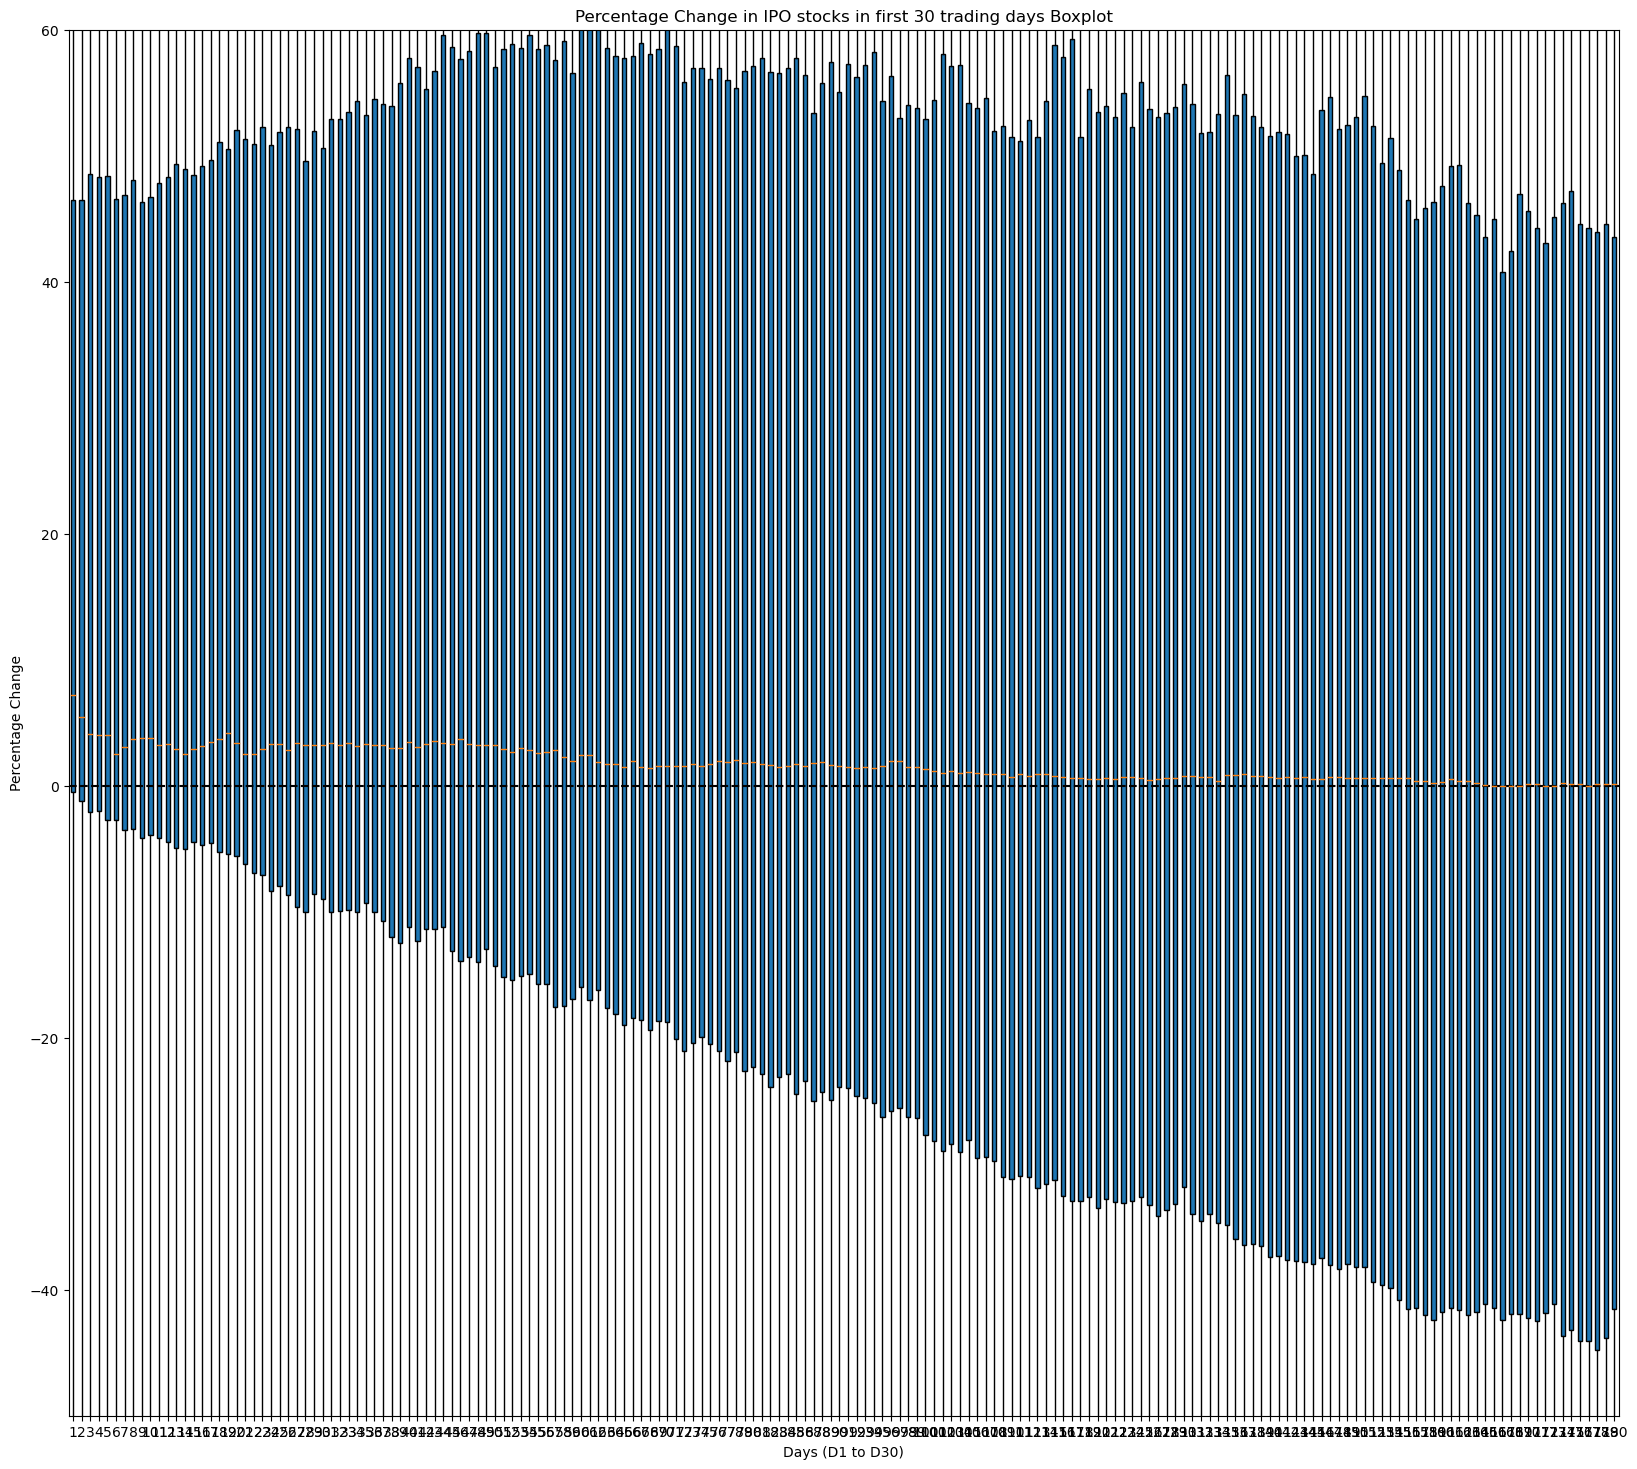

In [9]:
import matplotlib.pyplot as plt

# Set the figure size for the plot
plt.figure(figsize=(20, 18))  # Adjust width and height as needed

# Assuming your DataFrame is named Stock_percent_Df
# Extracting column names D1 to D30 for boxplot
data = [Stock_percent_Df[col].dropna().tolist() for col in Stock_percent_Df.columns[3:]]

# Creating a boxplot
plt.boxplot(data, patch_artist=True)

# Adding a center line at 0%
plt.axhline(y=0, color='black', linestyle='--')

# Adding labels and title
plt.xlabel('Days (D1 to D30)')
plt.ylabel('Percentage Change')
plt.title('Percentage Change in IPO stocks in first 30 trading days Boxplot')

# Set y-axis limits
plt.ylim(-50, 60)

# Show the plot
plt.show()